In [1]:
#import fwiVis.fwiVis as fv
import s3fs
s3 = s3fs.S3FileSystem(anon=False)
from math import cos, asin, sqrt
import re

import numpy as np
import geopandas as gpd
import pandas as pd
from matplotlib import pyplot as plt
import os
import rioxarray as rio
import xarray as xr
import rasterio
import glob
from shapely.errors import ShapelyDeprecationWarning
from shapely.geometry import Point
import warnings
import folium
import datetime
import time
from folium import plugins
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
warnings.filterwarnings("ignore", category=ShapelyDeprecationWarning) 
#import contextily as cx
from shapely.geometry import box
import sys
from datetime import datetime, timedelta
from itertools import chain
from bs4 import BeautifulSoup # I mamba installed bs4
import requests

from datetime import date


# sys.path.insert(0, '/projects/old_shared/fire_weather_vis/base-fwi-vis/')
# import fwiVis.fwiVis as fv

In [2]:
df = gpd.read_file("/projects/shared-buckets/gsfc_landslides/FEDSoutput-v3/Bolivia_Corrected/2024/CombinedLargefire/20241020PM/lf_perimeter.fgb")

#fl_df = gpd.read_file("/projects/shared-buckets/gsfc_landslides/FEDSoutput-v3/Bolivia_Corrected/2024/CombinedLargefire/20241020PM/lf_fireline.fgb")

In [3]:
df.columns

Index(['mergeid', 'ftype', 'n_pixels', 'n_newpixels', 'farea', 'fperim',
       'flinelen', 'duration', 'pixden', 'meanFRP', 't', 't_st', 't_ed',
       'fireID', 'isignition', 't_inactive', 'isactive', 'isdead',
       'mayreactivate', 'geom_counts', 'low_confidence_grouping', 'region',
       'primarykey', 'geometry'],
      dtype='object')

In [4]:
#!pip install lonboard

In [5]:
from lonboard import Map, PolygonLayer

In [ ]:
df.crs

In [ ]:
?PolygonLayer

In [8]:
# layer = PolygonLayer.from_geopandas(
#     df,
#     # get_line_width=20,  # width in default units (meters)
#     # line_width_min_pixels=0.2,  # minimum width when zoomed out
#     get_fill_color=[204, 251, 254, 15],  # light blue
#     get_line_color=[37, 36, 34]  # dark border color
# )

# m = Map(layer)
# m

In [9]:
df.columns

Index(['mergeid', 'ftype', 'n_pixels', 'n_newpixels', 'farea', 'fperim',
       'flinelen', 'duration', 'pixden', 'meanFRP', 't', 't_st', 't_ed',
       'fireID', 'isignition', 't_inactive', 'isactive', 'isdead',
       'mayreactivate', 'geom_counts', 'low_confidence_grouping', 'region',
       'primarykey', 'geometry'],
      dtype='object')

In [10]:
## Make a plot of active fireline through time

active_fire_length = df.groupby("t").flinelen.sum().reset_index()

In [ ]:
plt.plot(active_fire_length.t.astype("datetime64[ns]"), active_fire_length.flinelen)
plt.ylabel("Total km of active fire line")
plt.title("Fires in Bolivia/Brazil/Paraguay (-54,-21.5) (-64.5,-12.2)")

In [ ]:

active_fire_length = df.groupby("t").n_newpixels.sum().reset_index()
plt.plot(active_fire_length.t.astype("datetime64[ns]"), active_fire_length.n_newpixels)
plt.ylabel("# of new pixels")
plt.title("Fires in Bolivia/Brazil/Paraguay (-54,-21.5) (-64.5,-12.2)")

In [13]:

per_fire_active_fire_length = df.groupby(["fireID"]).flinelen.max().reset_index()


In [ ]:
?per_fire_active_fire_length.flinelen.hist

In [18]:
df.groupby(["fireID"]).farea.max().reset_index().sort_values(by = ["farea"], ascending = False)

,fireID,farea
169,2354.0,46296.633842
153,1932.0,32755.324005
56,257.0,5137.007660
646,12134.0,3128.278289
584,10661.0,3073.748784
...,...,...
1342,24030.0,4.006908
488,9099.0,4.006121
1727,30831.0,4.005335
113,1227.0,4.004833


In [43]:
#test_df = df[df.fireID == 727.0]
fid = 31

In [46]:
df[df.fireID == fid]

,mergeid,ftype,n_pixels,n_newpixels,farea,fperim,flinelen,duration,pixden,meanFRP,...,isignition,t_inactive,isactive,isdead,mayreactivate,geom_counts,low_confidence_grouping,region,primarykey,geometry
22360,31.0,0,66409,4946,11110.597433,1300.118055,499.869129,128.0,5.977086,4.294298,...,0,21,0,1,0,NaN,0,Bolivia_NOAA20,Bolivia_NOAA20|31.0|2024-09-06T00:00:00,"MULTIPOLYGON (((4680100.901 -5661918.865, 4679..."
22361,31.0,0,67175,766,11233.491503,1272.998466,216.902784,128.5,5.979886,25.422063,...,0,21,0,1,0,NaN,0,Bolivia_NOAA20,Bolivia_NOAA20|31.0|2024-09-06T12:00:00,"MULTIPOLYGON (((4680104.545 -5661924.002, 4680..."
22362,31.0,0,71339,2400,11607.551491,1270.016916,381.190482,129.5,6.145913,30.812075,...,0,20,0,0,1,NaN,0,Bolivia_NOAA20,Bolivia_NOAA20|31.0|2024-09-07T12:00:00,"MULTIPOLYGON (((4686246.459 -5659705.925, 4686..."
22363,31.0,0,68939,1764,11441.104350,1263.054784,362.901984,129.0,6.025555,2.686485,...,0,20,0,0,1,NaN,0,Bolivia_NOAA20,Bolivia_NOAA20|31.0|2024-09-07T00:00:00,"MULTIPOLYGON (((4680104.545 -5661924.002, 4680..."
22364,31.0,0,81649,516,13282.639659,1406.418186,144.863436,138.5,6.147046,31.715019,...,0,11,0,0,1,NaN,0,Bolivia_NOAA20,Bolivia_NOAA20|31.0|2024-09-16T12:00:00,"MULTIPOLYGON (((4676038.267 -5582576.565, 4676..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51591,31.0,0,488,9,52.329746,53.477364,3.187140,61.0,9.325480,1.584444,...,0,88,0,1,0,2.0,0,Bolivia_NOAA20,Bolivia_NOAA20|31.0|2024-07-01T00:00:00,"MULTIPOLYGON (((4679302.994 -5666846.794, 4679..."
51592,31.0,0,488,0,52.329746,53.477364,3.187140,61.0,9.325480,NaN,...,0,88,0,1,0,10.0,1,Bolivia_NOAA20,Bolivia_NOAA20|31.0|2024-07-01T12:00:00,"MULTIPOLYGON (((4679302.994 -5666846.794, 4679..."
51593,31.0,0,489,1,52.329746,53.477364,3.187140,62.0,9.344590,4.400000,...,0,87,0,1,0,NaN,0,Bolivia_NOAA20,Bolivia_NOAA20|31.0|2024-07-02T00:00:00,"MULTIPOLYGON (((4679298.190 -5666837.288, 4679..."
51594,31.0,0,492,3,53.199647,55.519232,5.011493,62.5,9.248182,6.613333,...,0,87,0,1,0,NaN,0,Bolivia_NOAA20,Bolivia_NOAA20|31.0|2024-07-02T12:00:00,"MULTIPOLYGON (((4679298.152 -5666837.190, 4679..."


In [ ]:
test_df = df[df.fireID == fid]
test_df.t = test_df.t.astype("str")
test_df.t_st = test_df.t_st.astype("str")
test_df.t_ed = test_df.t_ed.astype("str")
test_df.t_inactive = test_df.t_inactive.astype("str")
#'t', 't_st', 't_ed',
#       'fireID', 'isignition', 't_inactive'
#
m = test_df.explore(style_kwds = {"fill":False})

In [48]:
m.save(f'/projects/old_shared/fire_weather_vis/Bolivia/biggest_fire_{fid}.html')

In [ ]:
#m

In [57]:
### Make a gif of Bolivia

perimeters = df[df.fireID == 2354.0]

# Filter out rows with None or empty geometries
perimeters = perimeters[perimeters['geometry'].notna() & ~perimeters['geometry'].is_empty]
perimeters = perimeters[perimeters['flinelen'] > 0]

# Convert 't' column to datetime for easier handling
perimeters['t'] = pd.to_datetime(perimeters['t'])

# Sort the data by date
perimeters = perimeters.sort_values(by='t')


# Function to add black outline to text
def draw_text_with_outline(ax, text, x, y, fontsize=14, fontweight='bold', fontcolor='white', outlinecolor='black'):
    from matplotlib.patheffects import withStroke
    ax.text(x, y, text, verticalalignment='top', horizontalalignment='right',
            transform=ax.transAxes, fontsize=fontsize, fontweight=fontweight, color=fontcolor,
            path_effects=[withStroke(linewidth=3, foreground=outlinecolor)])

# Color interpolation function for creating a gradient of darker colors
def generate_darker_colors(base_color, num_colors):
    base_rgb = np.array(mcolors.hex2color(base_color))
    colors = []
    for i in range(num_colors):
        factor = (i + 1) / num_colors
        darker_rgb = base_rgb * (1 - factor)
        colors.append(mcolors.to_hex(darker_rgb))
    return colors

def generate_color_scale(base_color, num_colors):
    base_rgb = np.array(mcolors.hex2color(base_color))
    colors = []
    for i in range(num_colors):
        factor = (i + 1) / num_colors
        darker_rgb = base_rgb * (1 - factor)
        colors.append(mcolors.to_hex(darker_rgb))
    return colors


import os


def make_plot(i, date, crs,  output_dir, intermediate_dir, inset_bounds, width, height, growth_style, x_min, y_min, x_max, y_max, num_dates,  base_color, darker_colors, final_plot = False, date_min = None) :
        fig, ax = plt.subplots(1, 1, figsize=(width, height))  # Increase figure size for better visibility #26.67 x 15

        # Load preprocessed clipped perimeters for the current date
        current_perimeters = gpd.read_file(os.path.join(intermediate_dir, f'clipped_perimeters_{i}.geojson'))

        # Plot all previous perimeters with unique darker colors
        for j in range(i-1, -1, -1):  # Iterate in reverse order to plot oldest on top
            if final_plot:
                past_color = darker_colors[j]
                past_style = {
                    'edgecolor': past_color,
                    'facecolor': 'none',
                    'alpha': 0.7,
                    'linewidth': 1
                }
                # past_style = growth_style
            else:
                past_color = darker_colors[j]
                past_style = {
                    'edgecolor': past_color,
                    'facecolor': past_color,
                    'alpha': 0.7,
                    'linewidth': 1
                }
            past_perimeters = gpd.read_file(os.path.join(intermediate_dir, f'clipped_perimeters_{j}.geojson'))
            past_perimeters.plot(ax=ax, **past_style, aspect=1)

        # Plot the current growth layer
        current_perimeters.plot(ax=ax, **growth_style, aspect=1)

        # Set fixed extent to ensure basemap remains consistent
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)

        # Add OSM HOT basemap
        ctx.add_basemap(ax, crs=crs, source=ctx.providers.Esri.WorldImagery, attribution="", zoom=11)

        # Remove axis borders and labels
        ax.set_aspect('equal')
        ax.axis('off')

        # Add formatted date label in the top right corner
        formatted_date = date.strftime('%B %d, %Y')
        if(final_plot):
            first_date = date - timedelta(days = i/2)
            formated_first = first_date.strftime('%B %d, %Y')
            draw_text_with_outline(ax, f"{formated_first} - {formatted_date}", 0.95, 0.95)
        else:
            draw_text_with_outline(ax, f"{formatted_date}", 0.95, 0.95)

        
        
            

        # Add an inset axis for the overview map
        inset_ax = inset_axes(ax, width="25%", height="25%", loc='lower left', borderpad=2)

        # Plot the overview map in the inset axis
        if (inset_bounds is not None):
            
            inset_x_max = inset_bounds[0]
            inset_x_min = inset_bounds[1]
            inset_y_max = inset_bounds[2]
            inset_y_min = inset_bounds[3]
        else:
            
            inset_x_min = total_bounds[0] - 5
            inset_y_min = total_bounds[1] - 5
            inset_x_max = total_bounds[2] + 5
            inset_y_max = total_bounds[3] + 5
        inset_ax.set_xlim(inset_x_min, inset_x_max)
        inset_ax.set_ylim(inset_y_min, inset_y_max)
        ctx.add_basemap(inset_ax, crs=crs, source=ctx.providers.NASAGIBS.BlueMarble, zoom = 4,interpolation='sinc', attribution="") #, zoom = 4,  interpolation='sinc' 
        inset_ax.set_aspect('equal'), 
        inset_ax.axis('off')

        # Draw a red box around the affected area
        inset_ax.add_patch(Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                                     edgecolor='red', facecolor='none', linewidth=2))

        # Add a border around the inset
        inset_border = Rectangle((0, 0), 1, 1, transform=inset_ax.transAxes,
                                 facecolor='none', edgecolor='black', linewidth=2, clip_on=False)
        inset_ax.add_patch(inset_border)

        # Save frame
        if(final_plot):
            print("altering i for a one-off -- if regenerating take out i alteration")
            i = i + 1
        frame_path = os.path.join(output_dir, f'frame_{i:03d}.png')
        plt.savefig(frame_path, dpi=(3840/width), bbox_inches='tight', pad_inches=0)
        plt.show()
        plt.close(fig)

#[-44.8, -85.39, -8.17, -23.9]
def generate_gif(perimeters, inset_bounds = [-36.86, -85.39, 6, -33],  output_dir = 'frames_new',intermediate_dir = 'intermediate_clipped_data',  width = 26.67, height = 15):


    # Initialize cumulative perimeter
    cumulative_perimeter = gpd.GeoDataFrame(geometry=[], crs=perimeters.crs)


    # Prepare intermediate data directory
    #intermediate_dir = 'intermediate_clipped_data'
    if not os.path.exists(intermediate_dir):
        os.makedirs(intermediate_dir)

    # Preprocess each perimeter
    dates = perimeters['t'].unique()
    for i, date in enumerate(dates):
        
        if (os.path.exists(intermediate_dir) &  os.path.exists(output_dir)):
            frames = os.listdir(os.path.abspath(output_dir))
            jsons = os.listdir(os.path.abspath(intermediate_dir))
            if (any(str(i) in s for s in jsons)):
                print(f'Skipping clipped_perimeters_{i} because it already exists')
                continue
                
        
        
        # Filter for current date's data
        current_perimeters = perimeters[perimeters['t'] == date]

        # Clip current perimeters with cumulative perimeter
        if not cumulative_perimeter.empty:
            print("the rounding this did not work. Hope this is fine!")
            # try:
            #     current_perimeters = gpd.overlay(current_perimeters, cumulative_perimeter, how='difference', keep_geom_type=False)
            # except:
            #     from shapely.geometry import shape, mapping
            #     def around(geom,p):
            #         geojson = mapping(geom)
            #         geojson['coordinates'] = np.round(np.array(geojson['coordinates']),p)
            #         return  shape(geojson)
            #     perimeters.geometry= perimeters.geometry.apply(lambda x: around(x,4))
            # from shapely.geometry import shape, mapping
            # def around(geom,p):
            #     geojson = mapping(geom)
            #     geojson['coordinates'] = np.round(np.array(geojson['coordinates'], dtype = "float64"), p)
            #     return  shape(geojson)
            # perimeters.geometry= perimeters.geometry.apply(lambda x: around(x,4))

        # Save the clipped current perimeters
        current_perimeters.to_file(os.path.join(intermediate_dir, f'clipped_perimeters_{i}.geojson'), driver='GeoJSON')

        # Update cumulative perimeter
        cumulative_perimeter = gpd.GeoDataFrame(pd.concat([cumulative_perimeter, current_perimeters], ignore_index=True))


    # Generate a list of darker colors for each time step
    base_color = '#f77f00'
    num_dates = len(perimeters['t'].unique())
    darker_colors = generate_darker_colors(base_color, num_dates)[::-1]

    # Prepare output directory for frames

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Define the style for the current growth layer
    growth_style = {
        'edgecolor': '#f94144',
        'facecolor': base_color,
        'alpha': 0.7,
        'linewidth': 2
    }

    # Calculate the overall bounding box with a buffer
    total_bounds = perimeters.total_bounds

    #### IMPORTANT: Adjust this buffer value as needed, to give extra breathing room around the edge of the map ####
    buffer = 0.1

    x_min, y_min, x_max, y_max = total_bounds[0] - buffer, total_bounds[1] - buffer, total_bounds[2] + buffer, total_bounds[3] + buffer

    # Create frames
    dates = perimeters['t'].unique()
    for i, date in enumerate(dates):
        if (os.path.exists(intermediate_dir) &  os.path.exists(output_dir)):
            frames = os.listdir(os.path.abspath(output_dir))
            if (any(str(i) in s for s in frames)):
                print(f'Skipping frame_{i} because it already exists')
                continue
        make_plot(i = i, date = date, crs = perimeters.crs.to_string(),  output_dir = output_dir, intermediate_dir = intermediate_dir, inset_bounds = inset_bounds, width = width, height = height, growth_style = growth_style, x_min = x_min, y_min = y_min, x_max = x_max, y_max = y_max, darker_colors = darker_colors, num_dates = num_dates, base_color = base_color)


    print(f"Static images saved in directory: {output_dir}")
    
def make_giff(perimeters, output_dir = "frames_new"):
    dates = perimeters['t'].unique()
    
    # Prepare output MP4 file
    output_mp4 = 'fire_animation.mp4'

    # Collect all frame file paths
    frames = [os.path.join(output_dir, f'frame_{i:03d}.png') for i in range(len(dates))]
    print(frames)

    # Create animated MP4
    with imageio.get_writer(output_mp4, mode='I', fps=1) as writer:  #Adjust FPS here
        for frame_path in frames:
            image = imageio.imread(frame_path)
            print(image)
            writer.append_data(image)

    print(f"Animated MP4 saved as: {output_mp4}")

In [58]:
# # !pip uninstall numpy
# #!pip install numpy==1.23.1

# import matplotlib.colors as mcolors
# import imageio.v2 as imageio
# import contextily as ctx
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# from matplotlib.patches import Rectangle
# perimeters.crs

# #inset_bounds = [-36.86, -85.39, 6, -33],  output_dir = 'frames_new',intermediate_dir = 'intermediate_clipped_data', 
# ### Make all the figures for the gif
# generate_gif(perimeters.to_crs(4326), output_dir = "frames_new_fresh", intermediate_dir="intermediate_dir_fresh",  width = 26.67, height = 15)

altering i for a one-off -- if regenerating take out i alteration


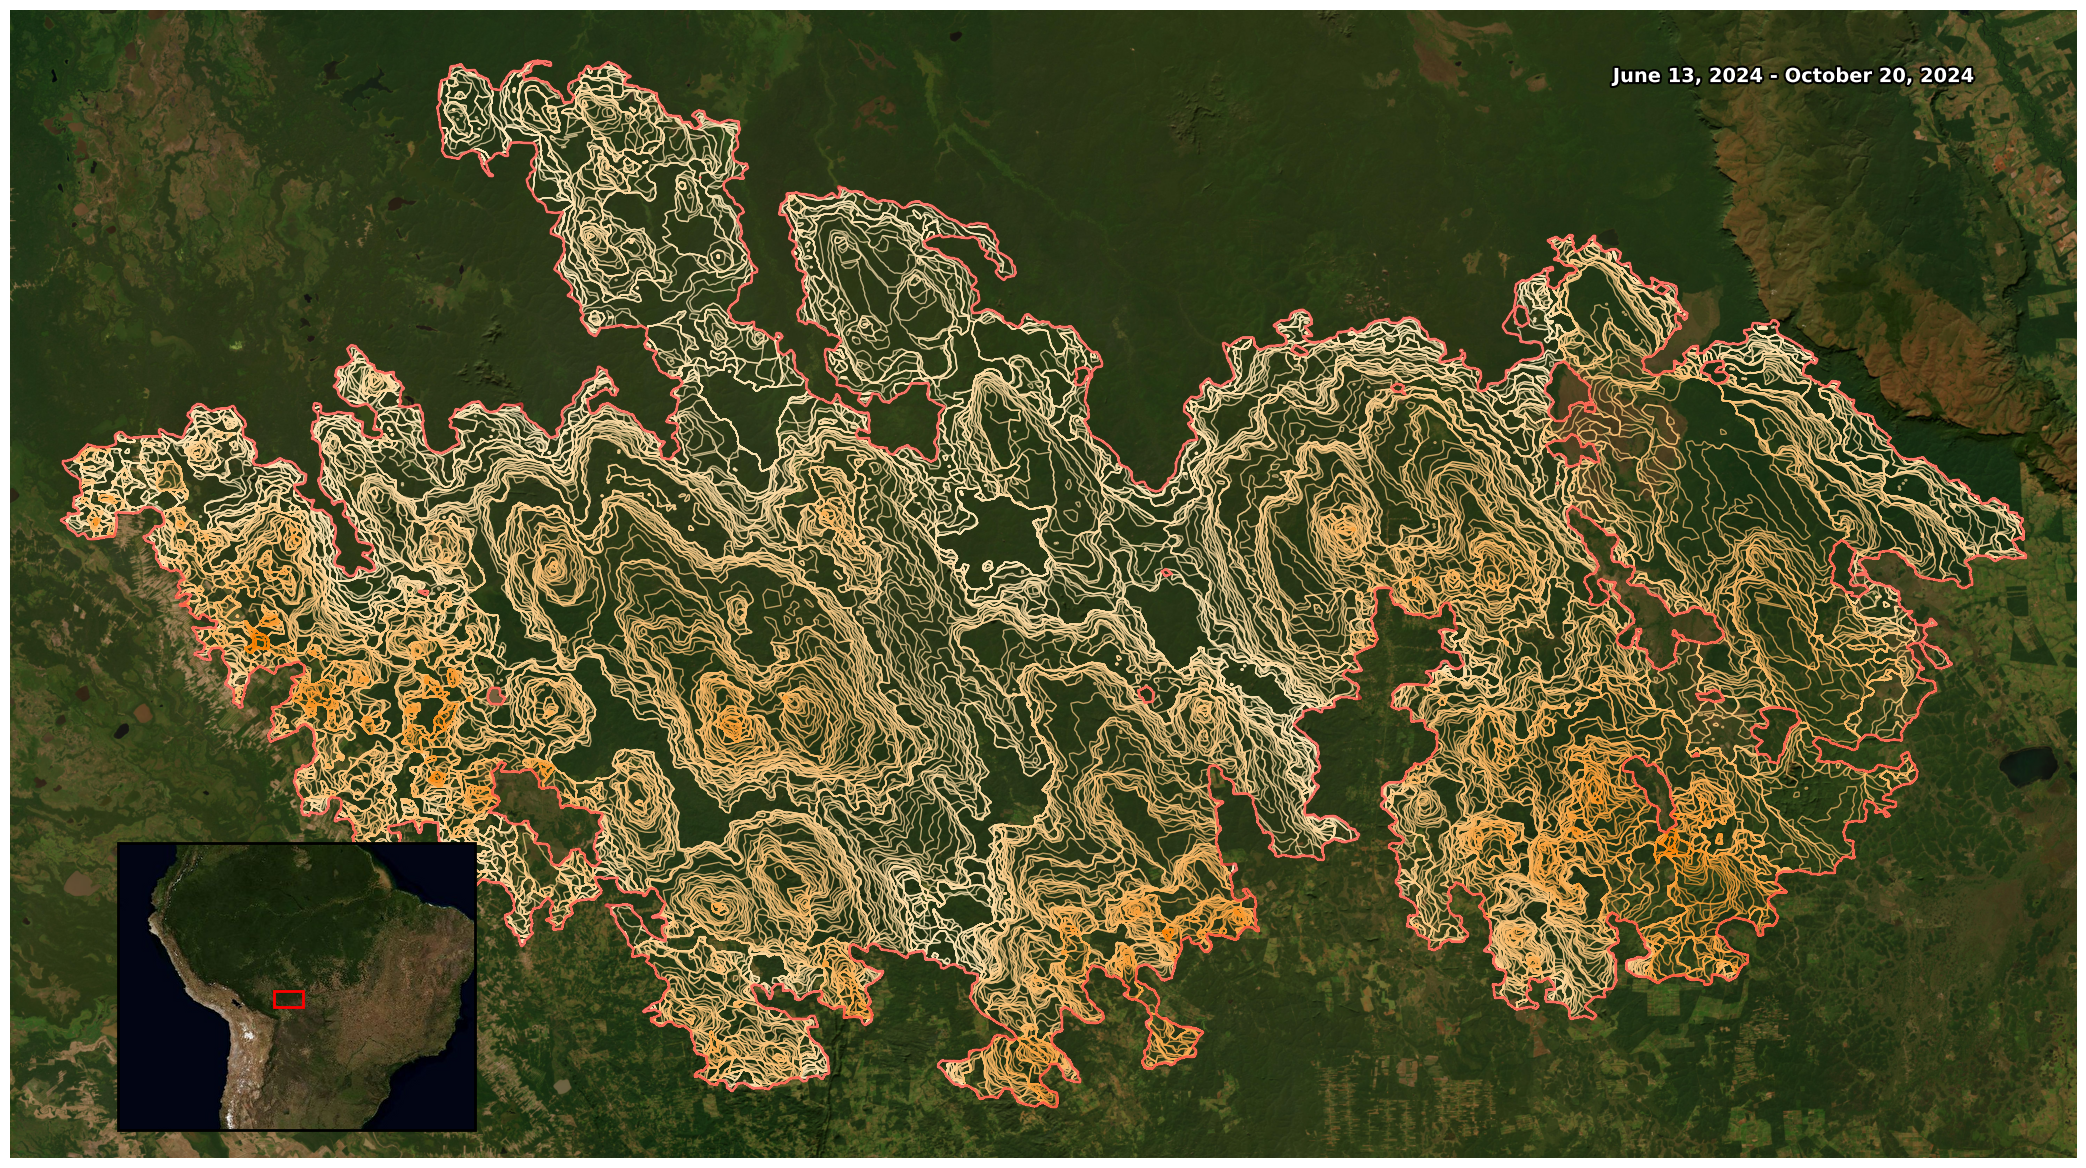

In [59]:
### Make a final frame with transparency to show off all the perimeters
perimeters = perimeters.to_crs(4326)


#### IMPORTANT: Adjust this buffer value as needed, to give extra breathing room around the edge of the map ####
total_bounds = perimeters.total_bounds
buffer = 0.1

x_min, y_min, x_max, y_max = total_bounds[0] - buffer, total_bounds[1] - buffer, total_bounds[2] + buffer, total_bounds[3] + buffer

base_color = '#f77f00'
num_dates = len(perimeters['t'].unique())
#darker_colors = generate_darker_colors(base_color, num_dates)[::-1]

def generate_color_scale(start_color, end_color, n_colors):
    # Create a linear colormap between the start and end colors
    cmap = mcolors.LinearSegmentedColormap.from_list('custom_colormap', [start_color, end_color], N=n_colors)
    
    # Generate the color scale by sampling colors from the colormap
    color_scale = [cmap(i / (n_colors - 1)) for i in range(n_colors)]
    return color_scale

darker_colors = generate_color_scale( start_color = '#f77f00', end_color = '#fff2cc', n_colors = num_dates)

growth_style = {
    'edgecolor': '#f94144',
    'facecolor': 'none',
    'alpha': 0.7,
    'linewidth': 2
}
make_plot(i = 258, date = perimeters.t.max(), crs = perimeters.crs.to_string(),   output_dir = "frames_new_fresh", intermediate_dir = "intermediate_dir_fresh", inset_bounds = [-36.86, -85.39, 6, -33], width = 26.67, height = 15, growth_style = growth_style, x_min = x_min, y_min = y_min, x_max = x_max, y_max = y_max, darker_colors = darker_colors, num_dates = num_dates, base_color = base_color, final_plot = True)


In [77]:
import zipfile

import os

def zip_files(file_paths, output_zip_path):
    with zipfile.ZipFile(output_zip_path, 'w') as zipf:
        for file in file_paths:
            zipf.write(file, os.path.basename(file))  # Add file to zip with only its basename
    print(f"Files zipped successfully into {output_zip_path}")

# Example usage

rep_path = [os.path.abspath("frames_new_fresh") + "/"] * len(os.listdir(os.path.abspath("frames_new_fresh")))
file_paths =  [a + b for a, b in zip(rep_path, os.listdir(os.path.abspath("frames_new_fresh")))]   # Replace with your actual file paths
output_zip_path = 'output.zip'  # Desired output zip file name

zip_files(file_paths, output_zip_path)

Files zipped successfully into output.zip


In [78]:
rep_path

['/projects/old_shared/fire_weather_vis/Bolivia/frames_new_fresh/',
 '/projects/old_shared/fire_weather_vis/Bolivia/frames_new_fresh/',
 '/projects/old_shared/fire_weather_vis/Bolivia/frames_new_fresh/',
 '/projects/old_shared/fire_weather_vis/Bolivia/frames_new_fresh/',
 '/projects/old_shared/fire_weather_vis/Bolivia/frames_new_fresh/',
 '/projects/old_shared/fire_weather_vis/Bolivia/frames_new_fresh/',
 '/projects/old_shared/fire_weather_vis/Bolivia/frames_new_fresh/',
 '/projects/old_shared/fire_weather_vis/Bolivia/frames_new_fresh/',
 '/projects/old_shared/fire_weather_vis/Bolivia/frames_new_fresh/',
 '/projects/old_shared/fire_weather_vis/Bolivia/frames_new_fresh/',
 '/projects/old_shared/fire_weather_vis/Bolivia/frames_new_fresh/',
 '/projects/old_shared/fire_weather_vis/Bolivia/frames_new_fresh/',
 '/projects/old_shared/fire_weather_vis/Bolivia/frames_new_fresh/',
 '/projects/old_shared/fire_weather_vis/Bolivia/frames_new_fresh/',
 '/projects/old_shared/fire_weather_vis/Bolivia/

In [ ]:
### Actually make the gif

#make_giff(perimeters, output_dir = "frames_new_fresh")

['frames_new_fresh/frame_000.png', 'frames_new_fresh/frame_001.png', 'frames_new_fresh/frame_002.png', 'frames_new_fresh/frame_003.png', 'frames_new_fresh/frame_004.png', 'frames_new_fresh/frame_005.png', 'frames_new_fresh/frame_006.png', 'frames_new_fresh/frame_007.png', 'frames_new_fresh/frame_008.png', 'frames_new_fresh/frame_009.png', 'frames_new_fresh/frame_010.png', 'frames_new_fresh/frame_011.png', 'frames_new_fresh/frame_012.png', 'frames_new_fresh/frame_013.png', 'frames_new_fresh/frame_014.png', 'frames_new_fresh/frame_015.png', 'frames_new_fresh/frame_016.png', 'frames_new_fresh/frame_017.png', 'frames_new_fresh/frame_018.png', 'frames_new_fresh/frame_019.png', 'frames_new_fresh/frame_020.png', 'frames_new_fresh/frame_021.png', 'frames_new_fresh/frame_022.png', 'frames_new_fresh/frame_023.png', 'frames_new_fresh/frame_024.png', 'frames_new_fresh/frame_025.png', 'frames_new_fresh/frame_026.png', 'frames_new_fresh/frame_027.png', 'frames_new_fresh/frame_028.png', 'frames_new_f

ValueError: needs one of codec_name or template

In [54]:
print(perimeters.t.astype("datetime64[ns]").max() - timedelta(days = 258/2))
perimeters.t.astype("datetime64[ns]").min()

2024-06-13 12:00:00


Timestamp('2024-06-13 12:00:00')

In [6]:
 make_giff

259

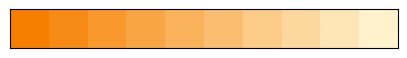

In [42]:


import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

def generate_color_scale(start_color, end_color, n_colors):
    # Create a linear colormap between the start and end colors
    cmap = mcolors.LinearSegmentedColormap.from_list('custom_colormap', [start_color, end_color], N=n_colors)
    
    # Generate the color scale by sampling colors from the colormap
    color_scale = [cmap(i / (n_colors - 1)) for i in range(n_colors)]
    return color_scale

# Example usage
start_color = '#f77f00'
end_color = '#fff2cc'
n_colors = 10

color_scale = generate_color_scale(start_color, end_color, n_colors)

# Display the color scale in a plot
fig, ax = plt.subplots(figsize=(5, 1))
ax.imshow([color_scale], extent=[0, 10, 0, 1])
ax.set_xticks([])
ax.set_yticks([])
plt.show()

In [2]:
import os

In [4]:
os.listdir("/projects/old_shared/fire_weather_vis/Bolivia/frames_new")

['frame_012.png',
 'frame_003.png',
 'frame_021.png',
 'frame_016.png',
 'frame_007.png',
 'frame_014.png',
 'frame_005.png',
 'frame_023.png',
 'frame_018.png',
 'frame_009.png',
 'frame_001.png',
 'frame_010.png',
 'frame_013.png',
 'frame_004.png',
 'frame_022.png',
 'frame_017.png',
 'frame_008.png',
 'frame_000.png',
 'frame_015.png',
 'frame_006.png',
 'frame_024.png',
 'frame_019.png',
 'frame_002.png',
 'frame_020.png',
 'frame_011.png']

In [8]:
os.path.abspath("frames_new")

'/projects/old_shared/fire_weather_vis/Bolivia/frames_new'

In [9]:
test = os.listdir("/projects/old_shared/fire_weather_vis/Bolivia/frames_new")

True

In [15]:
test

['frame_012.png',
 'frame_003.png',
 'frame_021.png',
 'frame_016.png',
 'frame_007.png',
 'frame_014.png',
 'frame_005.png',
 'frame_023.png',
 'frame_018.png',
 'frame_009.png',
 'frame_001.png',
 'frame_010.png',
 'frame_013.png',
 'frame_004.png',
 'frame_022.png',
 'frame_017.png',
 'frame_008.png',
 'frame_000.png',
 'frame_015.png',
 'frame_006.png',
 'frame_024.png',
 'frame_019.png',
 'frame_002.png',
 'frame_020.png',
 'frame_011.png']